# Day 2: Loss Functions + Optimizers + Key Terminologies + Types of Learning

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.cluster import KMeans
from sklearn.metrics import accuracy_score

## 2.1 Loss Functions

In [3]:
def mse(y_true, y_pred):
    return np.mean((y_true - y_pred) ** 2)

def mae(y_true, y_pred):
    return np.mean(np.abs(y_true - y_pred))

def binary_cross_entropy(y_true, y_pred):
    eps = 1e-9
    return -np.mean(y_true * np.log(y_pred + eps) + (1 - y_true) * np.log(1 - y_pred + eps))

y_true = np.array([1, 0, 1, 1])
y_pred = np.array([0.9, 0.2, 0.6, 0.4])

print("MSE:", mse(y_true, y_pred))
print("MAE:", mae(y_true, y_pred))
print("BCE:", binary_cross_entropy(y_true, y_pred))

MSE: 0.14250000000000002
MAE: 0.32499999999999996
BCE: 0.438905104021101


## 2.2 Gradient Descent Optimizer from Scratch

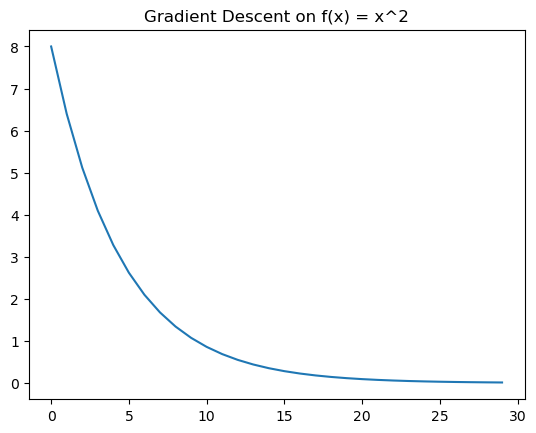

In [4]:
def gradient_descent(x_start, lr, epochs):
    x = x_start
    history = []
    for _ in range(epochs):
        grad = 2 * x  # derivative of x^2
        x = x - lr * grad
        history.append(x)
    return history

history = gradient_descent(x_start=10.0, lr=0.1, epochs=30)
plt.figure()
plt.plot(history)
plt.title("Gradient Descent on f(x) = x^2")
plt.show()

## 2.3 Parameters vs Hyperparameters, Epochs, Batches

In [5]:
X_train = np.random.randn(1000, 4)
y_train = np.random.randint(0, 2, 1000)

batch_size = 32
epochs = 5
num_batches = len(X_train) // batch_size

for epoch in range(epochs):
    for b_idx in range(num_batches):
        start = b_idx * batch_size
        end = start + batch_size
        X_batch = X_train[start:end]
        y_batch = y_train[start:end]

print("Epochs:", epochs, "| Batches per epoch:", num_batches)

Epochs: 5 | Batches per epoch: 31


## 2.4 Supervised Learning

In [6]:
X_sup, y_sup = make_classification(n_samples=200, n_features=4, random_state=1)
X_tr, X_te, y_tr, y_te = train_test_split(X_sup, y_sup, test_size=0.2, random_state=1)
clf = LogisticRegression().fit(X_tr, y_tr)
print("Supervised Learning Accuracy:", accuracy_score(y_te, clf.predict(X_te)))

Supervised Learning Accuracy: 0.775


## 2.5 Unsupervised Learning

In [7]:
X_unsup, _ = make_classification(n_samples=200, n_features=2, n_informative=2,
                                  n_redundant=0, random_state=1)
kmeans = KMeans(n_clusters=3, n_init=10, random_state=1).fit(X_unsup)
print("Cluster centers:\n", kmeans.cluster_centers_)

Cluster centers:
 [[ 1.58551434  0.32500125]
 [-0.64964119  0.98130782]
 [-0.5843812  -1.70094105]]


d:\minconds\envs\prac_eda\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
